<a href="https://colab.research.google.com/github/haniyawahabb/face-recognition/blob/main/face_recognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Facial Emotion Recognition using Transfer Learning (CNN)
**Domain:** Computer Vision / Deep Learning
**Approach:** Transfer Learning on top of MobileNetV2 (pretrained on ImageNet)
**Dataset:** FER-2013 (Facial Expression Recognition 2013) — 35,887 grayscale 48x48 images across 7 emotions

**Classes:** angry, disgust, fear, happy, neutral, sad, surprise

> Run this notebook in **Google Colab** with a GPU runtime: `Runtime > Change runtime type > GPU`.

**Pipeline:**
1. Get dataset (Kaggle API)
2. Preprocess (resize, grayscale to RGB, augment)
3. Build Transfer Learning model (MobileNetV2 base + custom classification head)
4. Train (feature extraction phase)
5. Fine-tune (unfreeze top layers)
6. Evaluate (accuracy, confusion matrix, classification report)
7. Save model + run inference on a sample image / webcam

## 1. Setup & Imports

In [20]:
!pip install -q kaggle tensorflow opencv-python-headless

import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix

print('TensorFlow version:', tf.__version__)
print('GPU available:', tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU available: []


Step 2 — Dataset Download + CSV→Images Conversion (Cell 4)

In [21]:
!pip install -q gdown

import os
import numpy as np
import pandas as pd
from PIL import Image
import gdown

FILE_ID = '1V0ELMWF5qSmCF4rOuKChnizgp-w49I5a'  # public fer2013.csv mirror
CSV_PATH = 'fer2013.csv'

if not os.path.exists(CSV_PATH):
    print('Downloading fer2013.csv ...')
    gdown.download(id=FILE_ID, output=CSV_PATH, quiet=False)

df = pd.read_csv(CSV_PATH)
print('Rows:', len(df))
print(df['Usage'].value_counts())

emotion_map = {0: 'angry', 1: 'disgust', 2: 'fear', 3: 'happy', 4: 'sad', 5: 'surprise', 6: 'neutral'}
label_names = [emotion_map[i] for i in range(7)]

base_dir = 'fer2013_data'
for split_name in ['train', 'test']:
    for cls in label_names:
        os.makedirs(f'{base_dir}/{split_name}/{cls}', exist_ok=True)

def usage_to_split(u):
    return 'train' if u == 'Training' else 'test'  # PublicTest + PrivateTest -> test

counts = {'train': 0, 'test': 0}
for _, row in df.iterrows():
    split_name = usage_to_split(row['Usage'])
    label = emotion_map[int(row['emotion'])]
    pixels = np.array(row['pixels'].split(), dtype=np.uint8).reshape(48, 48)
    img = Image.fromarray(pixels, mode='L').convert('RGB')
    img.save(f'{base_dir}/{split_name}/{label}/{counts[split_name]}.jpg')
    counts[split_name] += 1
    if counts[split_name] % 5000 == 0:
        print(f'{split_name}: saved {counts[split_name]} images')

print('Done. Images saved under', base_dir, counts)

Rows: 35887
Usage
Training       28709
PublicTest      3589
PrivateTest     3589
Name: count, dtype: int64


/tmp/ipykernel_1546/3095397160.py:36: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(pixels, mode='L').convert('RGB')


train: saved 5000 images
train: saved 10000 images
train: saved 15000 images
train: saved 20000 images
train: saved 25000 images
test: saved 5000 images
Done. Images saved under fer2013_data {'train': 28709, 'test': 7178}


Step 3 — Preprocessing & Data Generators

In [22]:
IMG_SIZE = 96
BATCH_SIZE = 64
TRAIN_DIR = 'fer2013_data/train'
TEST_DIR = 'fer2013_data/test'

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.15,
    horizontal_flip=True,
    validation_split=0.1
)

test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=(IMG_SIZE, IMG_SIZE), color_mode='rgb',
    batch_size=BATCH_SIZE, class_mode='categorical', subset='training', shuffle=True
)

val_gen = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=(IMG_SIZE, IMG_SIZE), color_mode='rgb',
    batch_size=BATCH_SIZE, class_mode='categorical', subset='validation', shuffle=False
)

test_gen = test_datagen.flow_from_directory(
    TEST_DIR, target_size=(IMG_SIZE, IMG_SIZE), color_mode='rgb',
    batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False
)

class_names = list(train_gen.class_indices.keys())
print('Classes:', class_names)

Found 25841 images belonging to 7 classes.
Found 2868 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.
Classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


Step 4 — Model Build

In [23]:
NUM_CLASSES = len(class_names)

base_model = MobileNetV2(input_shape=(IMG_SIZE, IMG_SIZE, 3), include_top=False, weights='imagenet')
base_model.trainable = False  # freeze for feature-extraction phase

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.4)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
predictions = Dense(NUM_CLASSES, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 96, 96, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 48, 48,    │        864 │ input_layer_3[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 48, 48,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 48, 48,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 48, 48,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 48, 48,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 48, 48,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 48, 48,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 48, 48,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 49, 49,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 24, 24,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 24, 24,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 24, 24,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 24, 24,    │      2,304 │ block_1_depthwis

 Total params: 2,624,839 (10.01 MB)

 Trainable params: 364,295 (1.39 MB)

 Non-trainable params: 2,260,544 (8.62 MB)

In [24]:
callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True),
    ModelCheckpoint('best_model_phase1.keras', monitor='val_accuracy', save_best_only=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6)
]

history1 = model.fit(
    train_gen,
    validation_data=val_gen,
    steps_per_epoch=100,       # CPU ke liye limit — poora dataset nahi, subset per epoch
    validation_steps=30,
    epochs=6,                  # CPU ke liye kam kiya (original: 15)
    callbacks=callbacks
)

Epoch 1/6
100/100 ━━━━━━━━━━━━━━━━━━━━ 60s 550ms/step - accuracy: 0.2886 - loss: 1.9025 - val_accuracy: 0.3630 - val_loss: 1.6463 - learning_rate: 0.0010
Epoch 2/6
100/100 ━━━━━━━━━━━━━━━━━━━━ 44s 442ms/step - accuracy: 0.3541 - loss: 1.6653 - val_accuracy: 0.3708 - val_loss: 1.5903 - learning_rate: 0.0010
Epoch 3/6
100/100 ━━━━━━━━━━━━━━━━━━━━ 45s 452ms/step - accuracy: 0.3634 - loss: 1.6335 - val_accuracy: 0.3901 - val_loss: 1.5561 - learning_rate: 0.0010
Epoch 4/6
100/100 ━━━━━━━━━━━━━━━━━━━━ 44s 440ms/step - accuracy: 0.3806 - loss: 1.5976 - val_accuracy: 0.3776 - val_loss: 1.5296 - learning_rate: 0.0010
Epoch 5/6
  4/100 ━━━━━━━━━━━━━━━━━━━━ 34s 360ms/step - accuracy: 0.4248 - loss: 1.5261

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


100/100 ━━━━━━━━━━━━━━━━━━━━ 11s 105ms/step - accuracy: 0.4023 - loss: 1.5619 - val_accuracy: 0.3870 - val_loss: 1.5188 - learning_rate: 0.0010
Epoch 6/6
100/100 ━━━━━━━━━━━━━━━━━━━━ 46s 436ms/step - accuracy: 0.3875 - loss: 1.5824 - val_accuracy: 0.3938 - val_loss: 1.5317 - learning_rate: 0.0010


In [25]:
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_ft = [
    EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True),
    ModelCheckpoint('best_model_finetuned.keras', monitor='val_accuracy', save_best_only=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-7)
]

history2 = model.fit(
    train_gen,
    validation_data=val_gen,
    steps_per_epoch=250,
    validation_steps=60,
    epochs=6,                  # pehle 4 tha
    callbacks=callbacks_ft
)

Epoch 1/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 148s 563ms/step - accuracy: 0.3516 - loss: 1.6439 - val_accuracy: 0.4031 - val_loss: 1.5671 - learning_rate: 1.0000e-05
Epoch 2/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 91s 365ms/step - accuracy: 0.3853 - loss: 1.5951 - val_accuracy: 0.4135 - val_loss: 1.5436 - learning_rate: 1.0000e-05
Epoch 3/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 139s 554ms/step - accuracy: 0.3885 - loss: 1.5750 - val_accuracy: 0.4313 - val_loss: 1.4999 - learning_rate: 1.0000e-05
Epoch 4/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 91s 364ms/step - accuracy: 0.3953 - loss: 1.5614 - val_accuracy: 0.4355 - val_loss: 1.4842 - learning_rate: 1.0000e-05
Epoch 5/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 169s 548ms/step - accuracy: 0.4033 - loss: 1.5353 - val_accuracy: 0.4209 - val_loss: 1.4826 - learning_rate: 1.0000e-05
Epoch 6/6
250/250 ━━━━━━━━━━━━━━━━━━━━ 92s 369ms/step - accuracy: 0.4154 - loss: 1.5270 - val_accuracy: 0.4268 - val_loss: 1.4699 - learning_rate: 1.0000e-05


In [26]:
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_ft = [
    EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True),
    ModelCheckpoint('best_model_finetuned.keras', monitor='val_accuracy', save_best_only=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-7)
]

history2 = model.fit(
    train_gen,
    validation_data=val_gen,
    steps_per_epoch=100,      # CPU-friendly, Step 5 jaisa
    validation_steps=30,
    epochs=4,                 # thodi si fine-tuning kaafi hai
    callbacks=callbacks_ft
)

Epoch 1/4
100/100 ━━━━━━━━━━━━━━━━━━━━ 72s 632ms/step - accuracy: 0.4066 - loss: 1.5422 - val_accuracy: 0.4359 - val_loss: 1.4427 - learning_rate: 1.0000e-05
Epoch 2/4
100/100 ━━━━━━━━━━━━━━━━━━━━ 61s 609ms/step - accuracy: 0.4119 - loss: 1.5365 - val_accuracy: 0.4297 - val_loss: 1.4341 - learning_rate: 1.0000e-05
Epoch 3/4
100/100 ━━━━━━━━━━━━━━━━━━━━ 82s 823ms/step - accuracy: 0.4081 - loss: 1.5247 - val_accuracy: 0.4167 - val_loss: 1.4429 - learning_rate: 1.0000e-05
Epoch 4/4
100/100 ━━━━━━━━━━━━━━━━━━━━ 61s 608ms/step - accuracy: 0.4123 - loss: 1.5276 - val_accuracy: 0.4219 - val_loss: 1.4516 - learning_rate: 1.0000e-05


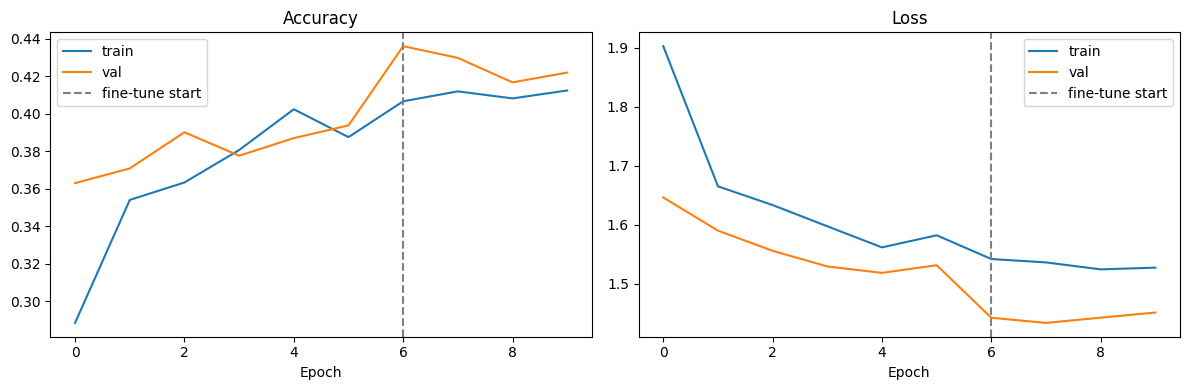

In [27]:
def plot_history(h1, h2):
    acc = h1.history['accuracy'] + h2.history['accuracy']
    val_acc = h1.history['val_accuracy'] + h2.history['val_accuracy']
    loss = h1.history['loss'] + h2.history['loss']
    val_loss = h1.history['val_loss'] + h2.history['val_loss']

    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].plot(acc, label='train'); ax[0].plot(val_acc, label='val')
    ax[0].axvline(len(h1.history['accuracy']), color='gray', linestyle='--', label='fine-tune start')
    ax[0].set_title('Accuracy'); ax[0].set_xlabel('Epoch'); ax[0].legend()

    ax[1].plot(loss, label='train'); ax[1].plot(val_loss, label='val')
    ax[1].axvline(len(h1.history['loss']), color='gray', linestyle='--', label='fine-tune start')
    ax[1].set_title('Loss'); ax[1].set_xlabel('Epoch'); ax[1].legend()

    plt.tight_layout()
    plt.show()

plot_history(history1, history2)

113/113 ━━━━━━━━━━━━━━━━━━━━ 29s 261ms/step - accuracy: 0.3898 - loss: 1.5618
Test Accuracy: 38.98%
113/113 ━━━━━━━━━━━━━━━━━━━━ 32s 277ms/step
              precision    recall  f1-score   support

       angry       0.29      0.16      0.21       958
     disgust       0.00      0.00      0.00       111
        fear       0.30      0.04      0.08      1024
       happy       0.45      0.75      0.56      1774
     neutral       0.38      0.25      0.30      1233
         sad       0.29      0.54      0.38      1247
    surprise       0.73      0.34      0.47       831

    accuracy                           0.39      7178
   macro avg       0.35      0.30      0.29      7178
weighted avg       0.39      0.39      0.35      7178



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


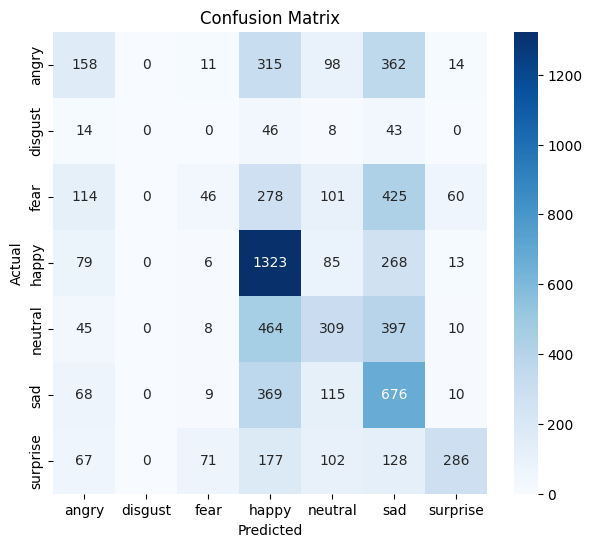

In [28]:
test_loss, test_acc = model.evaluate(test_gen)
print(f'Test Accuracy: {test_acc*100:.2f}%')

y_pred_probs = model.predict(test_gen)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_gen.classes

print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.title('Confusion Matrix')
plt.show()

In [29]:
model.save('emotion_recognition_mobilenetv2.keras')
print('Model saved.')

Model saved.


Saving happy.jpg to happy (3).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 984ms/step


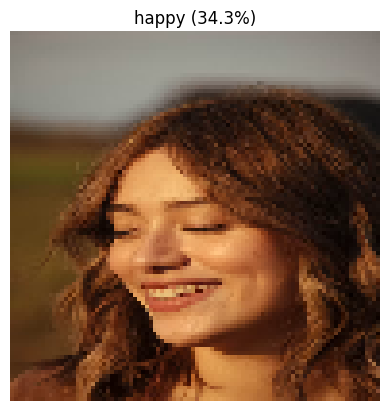

('happy', np.float32(0.34336844))

In [30]:
from tensorflow.keras.preprocessing import image as kimage

def predict_emotion(img_path):
    img = kimage.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
    arr = kimage.img_to_array(img)
    arr = preprocess_input(arr)
    arr = np.expand_dims(arr, axis=0)
    pred = model.predict(arr)[0]
    idx = np.argmax(pred)
    plt.imshow(img); plt.axis('off')
    plt.title(f'{class_names[idx]} ({pred[idx]*100:.1f}%)')
    plt.show()
    return class_names[idx], pred[idx]

# Colab mein image upload karo:
from google.colab import files
uploaded = files.upload()
img_path = list(uploaded.keys())[0]
predict_emotion(img_path)